# Práctica 3 - Ejercicio 1

Asignatura: Programación para la Inteligencia Artificial

Alumno: Jose Francisco Aguilar Granados

Típicamente el Aprendizjae Profundo se utiliza en problemas supervisados (conocemos la entrada y la salida para los datos de entrenamiento, validación y test). Este planteamiento tiene el problema de requerir que los datos hayan sido previamente etiquetados. Sin embargo, hay modelos neuronales que no tienen esta restricción.

Un Autocodificador (*Autoencoder*) es una red neuronal que se entrena para aprender la función identidad. Típicamente se puede dividir en dos secciones simétricas: una primera parte que codifica progresivamente la entrada a un espacio de menos dimensiones (denominado espacio latente) y una segunda parte que decodifica de vuelta al espacio de dimensiones original.

$x = d_{\theta_{1}}(e_{\theta_{2}}(x))$

Como aprende la función identidad, no requiere etiquetado para su entrenamiento.

Un Autocodificador con eliminación de ruido (*Denoising Autoencoder*) es una red neuronal que se entrena para eliminar el ruido de unos datos de entrada.

$x = d_{\theta_{1}}(e_{\theta_{2}}(\hat{x}))$

El objetivo de esta práctica es definir y entrenar un Autocodificar con eliminación de ruido capaz de lidiar con ruido gaussiano de media $\mu=0$ y desviación típica $\sigma=0.2$ para el conjunto de datos Fashion-MNIST (https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html). El autocodificador debe componerse de neuronas lineales y el espacio latente debe ser de 8 dimensiones.

Para evaluar la efectividad del modelo entrenado se deben utilizar todos los ejemplos del conjunto de test y el error absoluto. Se recomienda incluir el código necesario para mostrar un ejemplo cualquiera del conjunto de test con ruido, sin ruido y el resultado del autocodificador.

Una vez entrenado, se debe mostrar la relación entre las componentes de las codificaciones del conjunto de test con la clase asociada a dichas codificaciones. Se recomienda hacer gráficas 2D cuyos ejes muestren los valores de 2 componentes y muestren la clase como el color de cada punto.

El cuaderno entregado debe llamarse ApellidosNombrePractica3Ejercicio1.ipynb

In [ ]:

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
import numpy as np

drive.mount('/content/drive')
workpath = '/content/drive/MyDrive/Work/Docencia UMA/2025-2026/Programacion para la IA/data'

train_dataset = datasets.FashionMNIST(root=workpath, train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root=workpath, train=False, download=True, transform=transforms.ToTensor())
print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Número de ejemplos en entrenamiento: 60000
Número de ejemplos en test: 10000


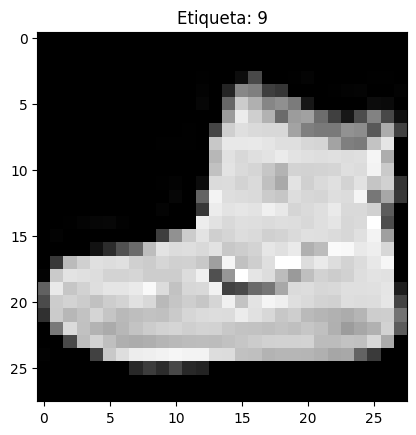

In [ ]:
image, label = train_dataset[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.title(f"Etiqueta: {label}")
plt.show()

In [ ]:
class miDataset(Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y

  def __len__(self):
    # La longitud del Dataset coincide con el número de elementos del vector x.
    return len(self.x)

  def __getitem__(self, idx):
    x_sample = self.x[idx]
    y_sample = self.y[idx]
    return x_sample, y_sample

In [ ]:
#En este paso vamos a añadir el ruido
imagenes_noise = []
imagenes = []
for imagen,label in train_dataset:
  imagenes.append(imagen)
  imagen = imagen + torch.normal(mean=0, std=0.2, size=imagen.shape)
  imagen = torch.clamp(imagen, 0, 1)
  imagenes_noise.append(imagen)

#imagenes_noise es una lista con todas las imagenes del dataset y su ruido

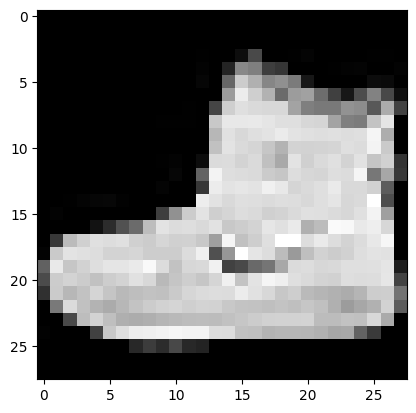

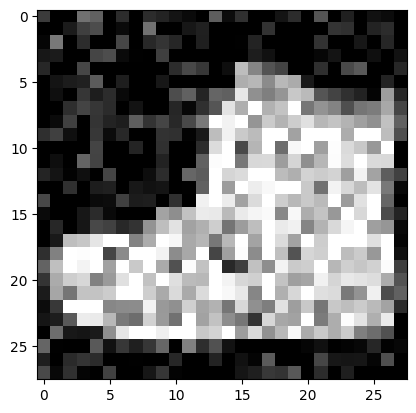

In [ ]:
image = imagenes[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.show()

image = imagenes_noise[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.show()

In [ ]:
def split_dataset(dataset, split_share=0.5):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

In [ ]:
train_dataset = miDataset(imagenes_noise, imagenes)

val_dataset,train_dataset = split_dataset(train_dataset, split_share=0.1)

print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en validación: {len(val_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")

Número de ejemplos en entrenamiento: 54028
Número de ejemplos en validación: 5972
Número de ejemplos en test: 10000


In [ ]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_y = []
    self.cuda_x = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc="Moving to GPU"):
      self.cuda_x.append(x.to(self.device))
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]


In [ ]:
'''
esta función es la que nos va a permitir ajustar nuestras funciones con los
parámetros que consideremos. Además nos ofrecerá la evolución del error durante el
entrenamiento

'''

def learning_loop_with_val(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer):
  train_loss_list = []
  val_loss_list = []
  opt = optimizer(
    model.parameters(),
    lr=learning_rate
  )

  for epoch in tqdm(range(epochs), desc="epoch:"):
    train_step_loss_list = []
    for x_train_true, y_train_true in train_dataloader:
      y_pred = model(x_train_true)                              # Forward
      opt.zero_grad()
      loss = loss_fn(y_pred, y_train_true)
      loss.backward()                                     # Backward
      train_step_loss_list.append(loss.clone().detach())
      opt.step()
    train_loss_list.append(torch.tensor(train_step_loss_list).mean())

    # Realizaremos una época de validación cada 10 pasos de entrenamiento para
    # minimizar los cálculos que no son estrictamente necesarios.
    if epoch % 10 == 0:
      val_step_loss_list = []
      with torch.no_grad():
        for x_val_true, y_val_true in val_dataloader:
          y_val_pred = model(x_val_true)
          loss_val = loss_fn(y_val_pred, y_val_true)
          val_step_loss_list.append(loss_val)
        val_loss_list.append(torch.tensor(val_step_loss_list).mean())

  return model, train_loss_list, val_loss_list


In [ ]:
images,label = train_dataset[30]
print(images.shape)
print(label.shape)

torch.Size([1, 28, 28])
torch.Size([1, 28, 28])


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")


batch_size = 1024
learning_rate = 1e-3
epochs = 200
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam

##################
gpu_train_dataset = CudaDataset(train_dataset, device)
gpu_val_dataset = CudaDataset(val_dataset, device)
##################
                                  ####
train_dataloader = DataLoader(gpu_train_dataset, batch_size = batch_size, shuffle=True)
val_dataloader = DataLoader(gpu_val_dataset, batch_size=batch_size, shuffle=True)

class DenoisingAutoencoder(torch.nn.Module):
    def __init__(self, input_dim=784, latent_dim=8, output_shape=(1, 28, 28)):
        super(DenoisingAutoencoder, self).__init__()
        self.output_shape = output_shape

        self.encoder = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(input_dim, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, latent_dim)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, input_dim),
            torch.nn.Sigmoid(),
            torch.nn.Unflatten(1, output_shape)  # Recuperar forma de imagen
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
# Mover modelo a GPU
model = DenoisingAutoencoder(input_dim=28*28, latent_dim=8)
model = model.to(device)
print(f"Modelo en: {next(model.parameters()).device}")


Usando dispositivo: cuda


Moving to GPU:   0%|          | 0/54028 [00:00<?, ?it/s]/tmp/ipython-input-4038462620.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cuda_y.append(torch.tensor(y, device=self.device))
Moving to GPU: 100%|██████████| 5972/5972 [00:00<00:00, 24715.34it/s]


Modelo en: cuda:0


In [ ]:
model, train_loss_list, val_loss_list = learning_loop_with_val(
    train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer
)

epoch:: 100%|██████████| 200/200 [00:59<00:00,  3.36it/s]


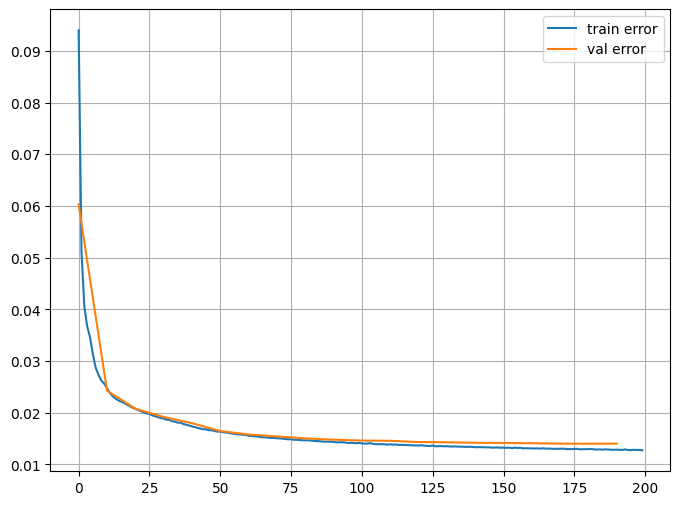

In [ ]:
def safe_convert(data):
        if isinstance(data, torch.Tensor):
            return data.cpu().detach().numpy() #como numpy no puede trabajar con gpu, lo cargamos en cpu. Detach desactiva los gradientes
        return data

train_loss_list = [safe_convert(x) for x in train_loss_list]
val_loss_list = [safe_convert(x) for x in val_loss_list]

plt.figure(figsize=(8,6))
plt.plot(range(len(train_loss_list)), train_loss_list, label="train error")
plt.plot(range(0, 10*len(val_loss_list), 10), val_loss_list, label="val error")
plt.legend()
plt.grid(True)
plt.show()

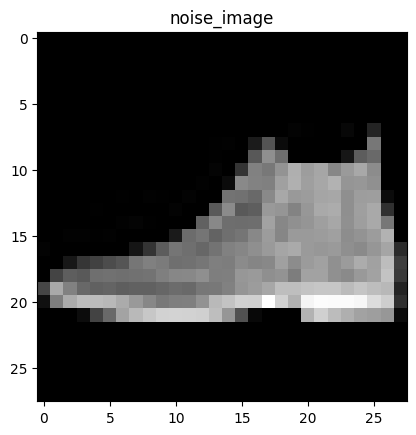

Moving to GPU:   0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipython-input-4038462620.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cuda_y.append(torch.tensor(y, device=self.device))
Moving to GPU: 100%|██████████| 10000/10000 [00:00<00:00, 25759.55it/s]


In [ ]:
#COMPROBAMOS LA SOLUCIÓN

image,label = test_dataset[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.title("noise_image")
plt.show()


#En este paso vamos a añadir el ruido a test
imagenes_noise = []
imagenes = []
for imagen,label in test_dataset:
  imagenes.append(imagen)
  imagen = imagen + torch.normal(mean=0, std=0.2, size=imagen.shape)
  imagen = torch.clamp(imagen, 0, 1)
  imagenes_noise.append(imagen)

nuevo_test_dataset = miDataset(imagenes_noise, imagenes)

gpu_test_dataset = CudaDataset(nuevo_test_dataset, device)
test_dataloader = DataLoader(gpu_test_dataset, batch_size=batch_size, shuffle=False)
#obtenemos la salida del modelo

entrada_list = []
salida_list = []
original_list = []

for x_true, y_true in test_dataloader:
  entrada_list.append(x_true)
  y_pred = model(x_true)
  salida_list.append(y_pred)
  original_list.append(y_true)

entrada_list = torch.cat(entrada_list, dim=0)
salida_list = torch.cat(salida_list, dim=0)
original_list = torch.cat(original_list, dim=0)


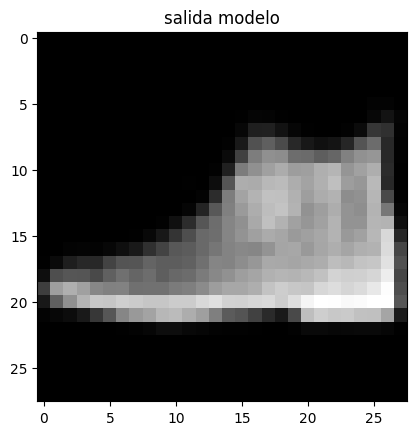

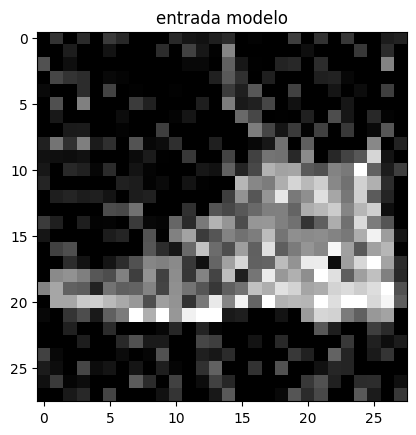

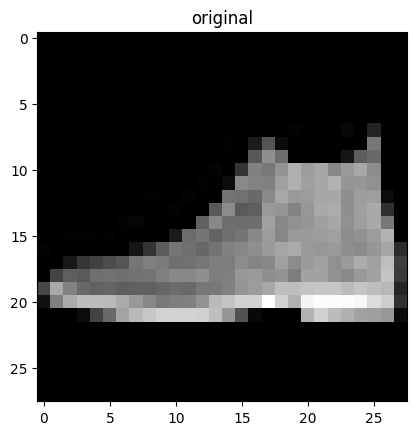

In [ ]:
#Este es el resultado que debería dar el modelo
def safe_convert(data):
        if isinstance(data, torch.Tensor):
            return data.cpu().detach().numpy()
        return data

y_pred = [safe_convert(x) for x in y_pred]
entrada_list = [safe_convert(x) for x in entrada_list]
salida_list = [safe_convert(x) for x in salida_list]
original_list = [safe_convert(x) for x in original_list]


image = salida_list[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.title("salida modelo")
plt.show()

image = entrada_list[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.title("entrada modelo")
plt.show()

image = original_list[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.title("original")
plt.show()



Este es el error del modelo 0.061163727194070816


Moving to GPU: 100%|██████████| 10000/10000 [00:01<00:00, 5038.14it/s]


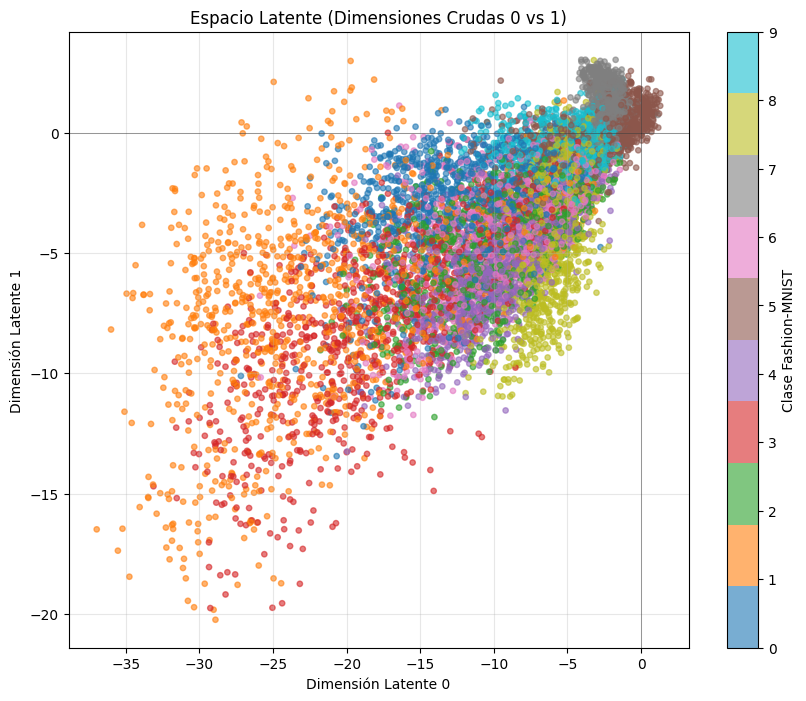

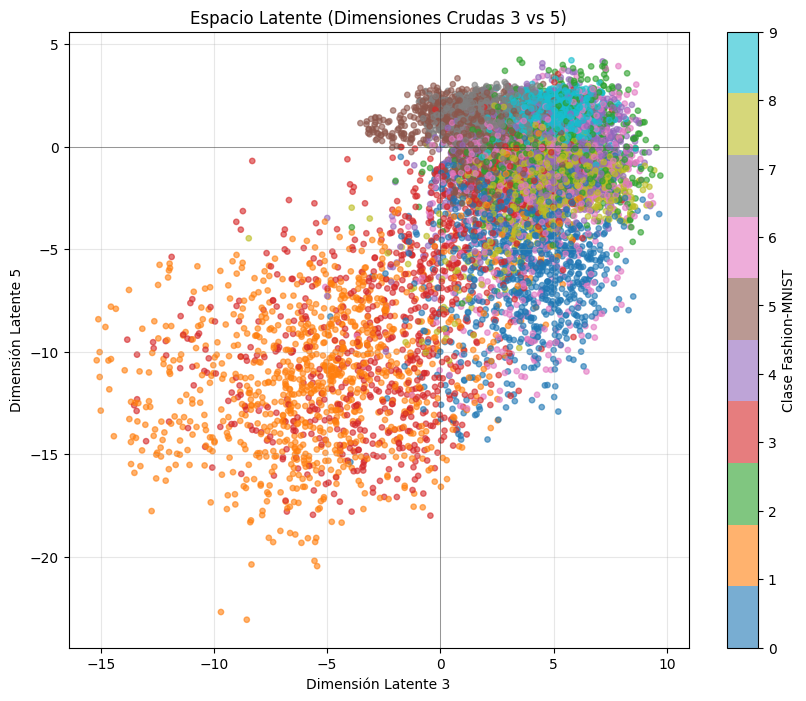

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

L1_loss = torch.nn.L1Loss()
salida_array = np.array(salida_list)
original_tensor = torch.tensor(original_list)
salida_tensor = torch.tensor(salida_list)



error = L1_loss(salida_tensor, original_tensor)

print(f"Este es el error del modelo {error}")


labels_list = []
encoded_list = []

gpu_test_dataset = CudaDataset(test_dataset, device)
plot_dataloader = DataLoader(gpu_test_dataset, batch_size=batch_size, shuffle=False)

for x_true, y_true in plot_dataloader:
  labels_list.append(y_true.cpu().detach().numpy())
  encode = model.encoder(x_true)
  encoded_list.append(encode)

labels_list = np.concatenate(labels_list, axis=0)
encoded_list = torch.cat(encoded_list, dim=0)

labels_list = [safe_convert(x) for x in labels_list]
encoded_list = [safe_convert(x) for x in encoded_list]

encoded_array = np.array(encoded_list)
labels_array = np.array(labels_list)

x_coords = encoded_array[:, 0]
y_coords = encoded_array[:, 1]


plt.figure(figsize=(10, 8))


scatter = plt.scatter(x_coords, y_coords,c=labels_list, cmap='tab10', alpha=0.6, s=15)

# Añadimos la barra de colores para saber qué es cada cosa
cbar = plt.colorbar(scatter)
cbar.set_label('Clase Fashion-MNIST')

plt.title('Espacio Latente (Dimensiones Crudas 0 vs 1)')
plt.xlabel('Dimensión Latente 0')
plt.ylabel('Dimensión Latente 1')
plt.grid(True, alpha=0.3)

# Opcional: Centrar la vista en (0,0) ya que es una Gaussiana normal
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)

plt.show()

x_coords = encoded_array[:, 3]
y_coords = encoded_array[:, 5]


plt.figure(figsize=(10, 8))


scatter = plt.scatter(x_coords, y_coords,c=labels_list, cmap='tab10', alpha=0.6, s=15)

# Añadimos la barra de colores para saber qué es cada cosa
cbar = plt.colorbar(scatter)
cbar.set_label('Clase Fashion-MNIST')

plt.title('Espacio Latente (Dimensiones Crudas 3 vs 5)')
plt.xlabel('Dimensión Latente 3')
plt.ylabel('Dimensión Latente 5')
plt.grid(True, alpha=0.3)

# Opcional: Centrar la vista en (0,0) ya que es una Gaussiana normal
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)

plt.show()
